In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [109]:
#x = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML1.1%20linear%20regression/data/x.csv')
#y = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML1.1%20linear%20regression/data/y.csv')

In [110]:
x.head()

0    1.462108
1    1.133769
2   -2.301539
3    1.744812
4    0.042214
Name: 0, dtype: float64

In [2]:
x = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML1.1%20linear%20regression/data/x.csv', index_col=0)['0']
y = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML1.1%20linear%20regression/data/y.csv', index_col=0)['0']

In [3]:
x.head()

0    1.462108
1    1.133769
2   -2.301539
3    1.744812
4    0.042214
Name: 0, dtype: float64

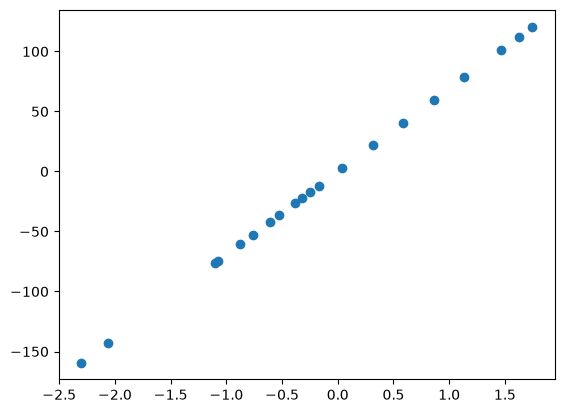

In [4]:
plt.figure()
plt.scatter(x, y)
plt.show()

In [21]:
import numpy as np

class Model(object):
    def __init__(self, b0=0, b1=0):
        self.b0 = b0
        self.b1 = b1

    def _validate_and_convert(self, data, name="data"):
        if isinstance(data, pd.DataFrame):
            if data.shape[1] != 1:
                raise ValueError(f"{name} должен содержать ровно один столбец, получено {data.shape[1]}")
            return data.iloc[:, 0].values
        elif isinstance(data, pd.Series):
            return data.values
        else:
            return np.asarray(data)
        
    def predict(self, X):
        return self.b0 + self.b1 * X

    def error(self, X, Y):
        return np.sum((self.predict(X) - Y) ** 2) / (2 * len(X))

    def fit(self, X, Y, accuracy=0.0001, max_steps=5000):
        steps, errors = [], []
        step = 0
        X = np.array(X)
        Y = np.array(Y)
        n = len(X)

        alpha = 1.0 
        
        prev_err = self.error(X, Y)
        
        while step < max_steps:
            predictions = self.predict(X)
            diff = predictions - Y
            
            dJ0 = np.sum(diff) / n
            dJ1 = np.sum(diff * X) / n 

            old_b0, old_b1 = self.b0, self.b1
            
            self.b0 -= alpha * dJ0 
            self.b1 -= alpha * dJ1

            new_err = self.error(X, Y)

            if new_err > prev_err:
                self.b0, self.b1 = old_b0, old_b1
                
                alpha /= 2.0
                
                if alpha < 1e-12:
                    break
                    
                continue 
            else:
                step += 1
                steps.append(step)
                errors.append(new_err)

                if abs(prev_err - new_err) < accuracy:
                    break
                    
                prev_err = new_err
            
        return steps, errors

    def plot(self, X, Y):
        X = self._validate_and_convert(X, "X")
        Y = self._validate_and_convert(Y, "Y")
        X0 = np.linspace(X.min(), X.max(), 100)
        Y0 = self.predict(X0)
        plt.figure()
        plt.scatter(X, Y)
        plt.plot(X0, Y0, 'r')
        plt.show()

In [22]:
hyp = Model()
steps, errors = hyp.fit(x, y)
J = hyp.error(x, y)
print("error after gradient descent:", J)
steps[-1]

error after gradient descent: 5.994964160459718e-06


8

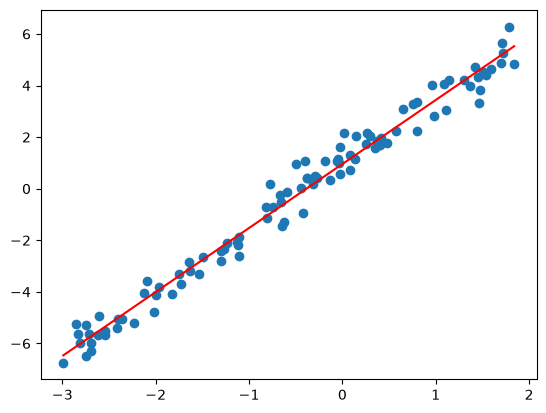

In [28]:
X_test = np.random.uniform(-3, 2, 100)
Y_test = 2.5 * X_test + 1.0 + np.random.normal(0, 0.5, 100)

model1 = Model()
model1.fit(X_test, Y_test)
model1.plot(X_test, Y_test)

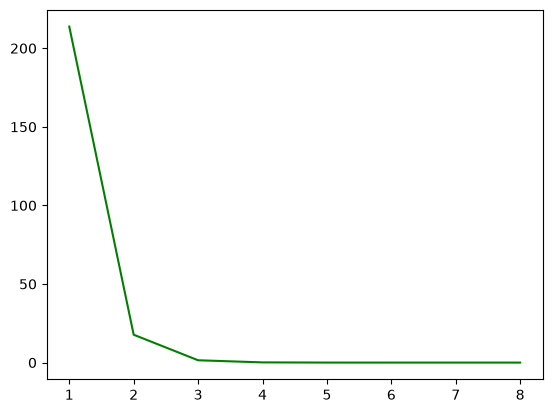

In [8]:
plt.figure()
plt.plot(steps, errors, 'g')
plt.show()

начальные значение параметров: 0|0
ошибка после градиетного спуска 0.04992531975655816
количество шагов градиентного спуска 4881



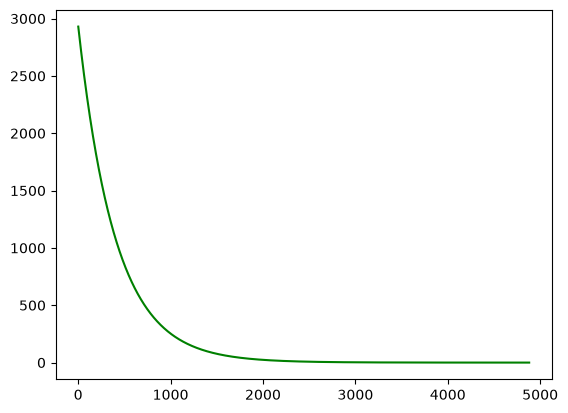

начальные значение параметров: 1|-1
ошибка после градиетного спуска 0.049707181756128115
количество шагов градиентного спуска 4873



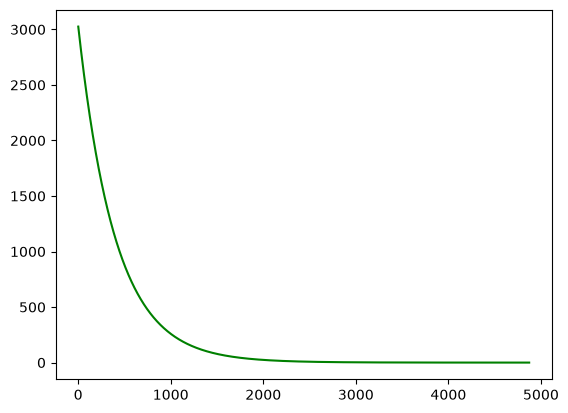

начальные значение параметров: 2|-2
ошибка после градиетного спуска 0.04950782372102281
количество шагов градиентного спуска 4865



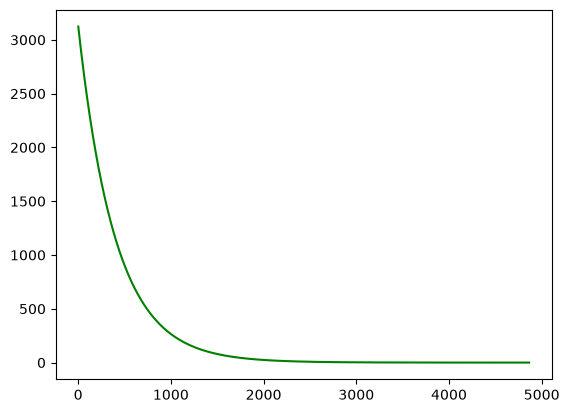

начальные значение параметров: 3|-3
ошибка после градиетного спуска 0.049228765969308586
количество шагов градиентного спуска 4858



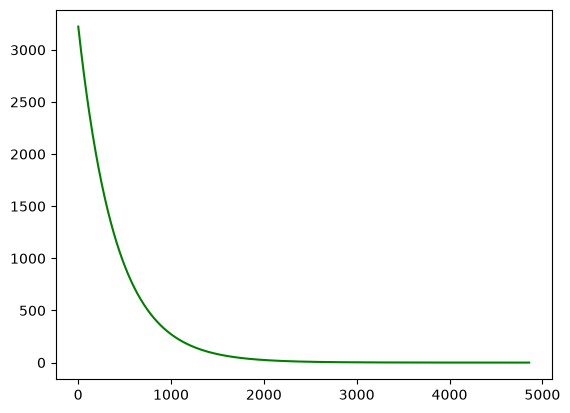

начальные значение параметров: 4|-4
ошибка после градиетного спуска 0.04907092241609044
количество шагов градиентного спуска 4850



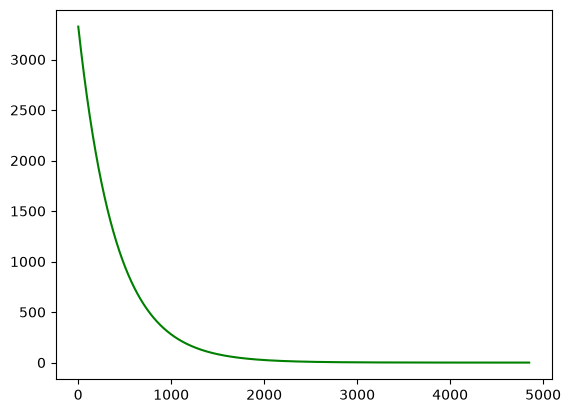

начальные значение параметров: 5|-5
ошибка после градиетного спуска 0.04883601221923307
количество шагов градиентного спуска 4843



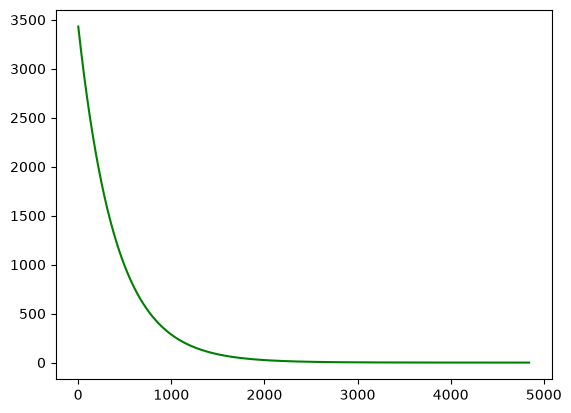

начальные значение параметров: 6|-6
ошибка после градиетного спуска 0.04852531808448312
количество шагов градиентного спуска 4837



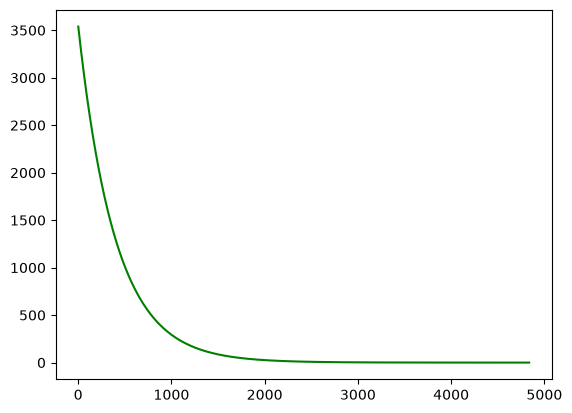

начальные значение параметров: 7|-7
ошибка после градиетного спуска 0.04823998596180159
количество шагов градиентного спуска 4831



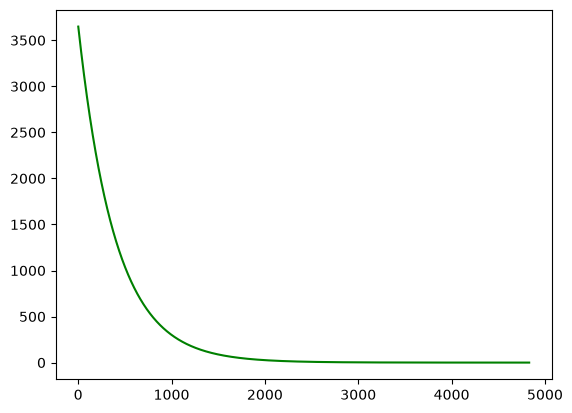

начальные значение параметров: 8|-8
ошибка после градиетного спуска 0.04798120703111199
количество шагов градиентного спуска 4825



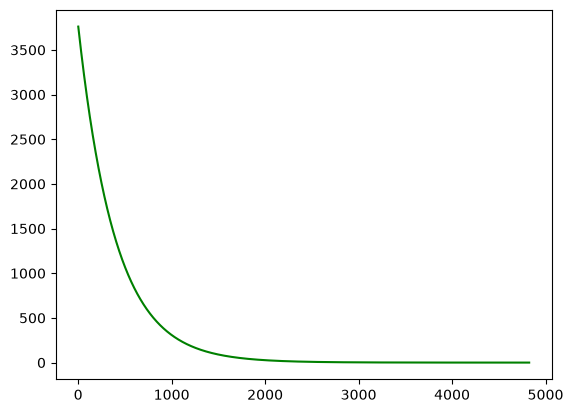

начальные значение параметров: 9|-9
ошибка после градиетного спуска 0.0477502054169884
количество шагов градиентного спуска 4819



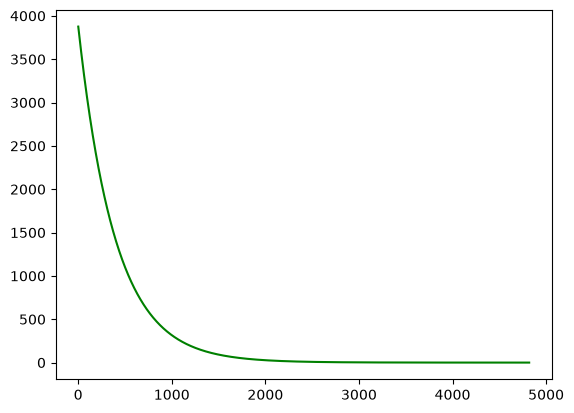

In [23]:
for i in range(10):
    M = Model(i, -i)
    steps, errors = M.fit(x, y)
    J = M.error(x, y)
    print(f"начальные значение параметров: {i}|{-i}")
    print(f"ошибка после градиетного спуска {J}")
    print(f"количество шагов градиентного спуска {steps[-1]}")
    print()
    plt.figure()
    plt.plot(steps, errors, "g")
    plt.show()

значения весов 1.0
ошибка после градиетного спуска 0.010306924606085437
количество шагов градиентного спуска 5



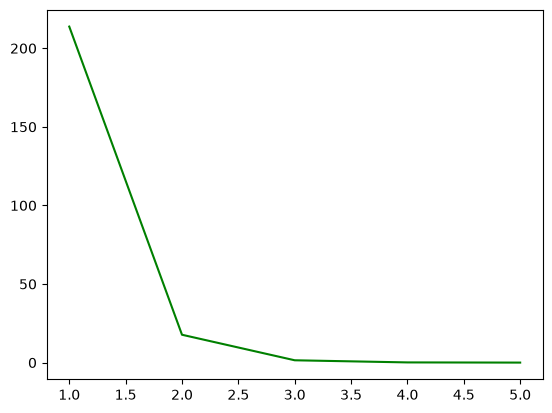

значения весов 0.1
ошибка после градиетного спуска 0.3620711964091713
количество шагов градиентного спуска 37



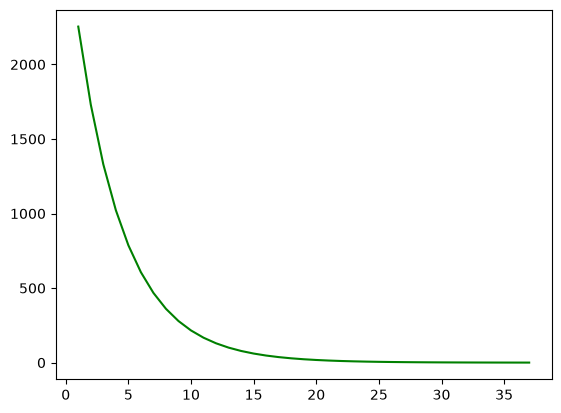

значения весов 0.010000000000000002
ошибка после градиетного спуска 0.46616638859625487
количество шагов градиентного спуска 377



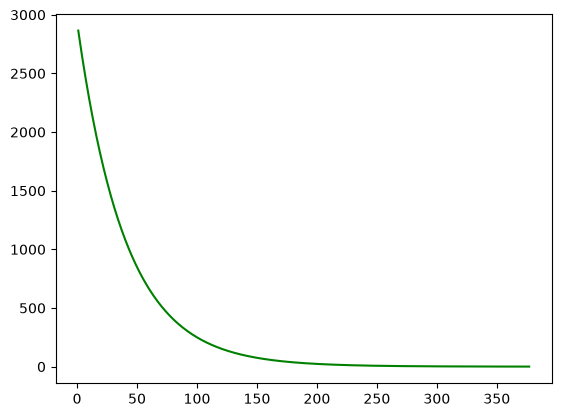

значения весов 0.0010000000000000002
ошибка после градиетного спуска 0.47536984815996747
количество шагов градиентного спуска 3779



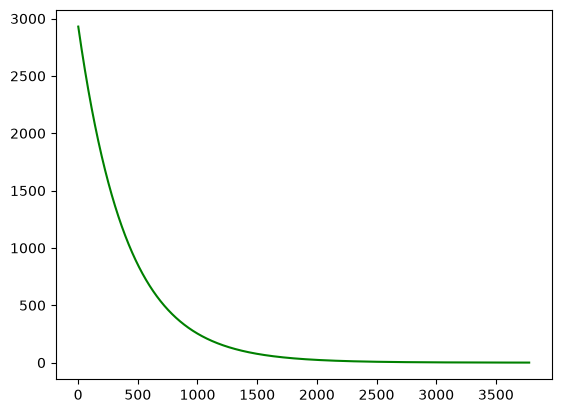

значения весов 0.00010000000000000002
ошибка после градиетного спуска 855.0919381472826
количество шагов градиентного спуска 5000



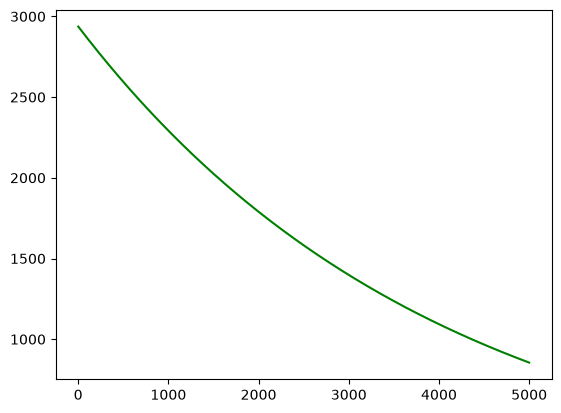

In [27]:
for i in range(5):
    M = Model()
    steps, errors = M.fit(x, y, alpha=0.1**i, accuracy=0.1**i)
    J = M.error(x, y)
    print(f"значения весов {0.1**i}")
    print(f"ошибка после градиетного спуска {J}")
    print(f"количество шагов градиентного спуска {steps[-1]}")
    print()
    plt.figure()
    plt.plot(steps, errors, "g")
    plt.show()